<a href="https://colab.research.google.com/github/Kaini9/Data-Analytics-Training/blob/main/Web-Scraping/Learning/Firecrawl_Books_Class_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Firecrawl for Beginners

### Building a real book dataset with Scrape, Crawl and Map

Prepared by Ananda Rimal

Today we take a real website and end the class with a CSV file full of books.

The website is books.toscrape.com. It is a practice shop made for learning
scraping, so we are allowed to scrape it. It holds 1000 books spread over 50
pages, with 20 books on every page.

What we will do:

1. **Scrape** one page and get the name, price and stock of its 20 books
2. **Crawl** several pages and collect all of their books into one CSV file
3. **Map** the site and see every link it contains


### The three words you must know

| Action | How many pages | What comes back | When to use it |
|---|---|---|---|
| **scrape** | one page | the content of that one page | you know the exact URL |
| **crawl** | many pages | the content of every page visited | you want a section or a whole site |
| **map** | many pages | only the links, no content | you want to see what pages exist |

Think of a book: map is the index, scrape is one page, crawl is the whole book.

Map is almost free, crawl is the most expensive. So the working order is always
map first, look, then crawl.


### Step 1. Install and import

In [ ]:
!pip install -q firecrawl-py pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.5/304.5 kB 5.9 MB/s eta 0:00:00


In [ ]:
from firecrawl import Firecrawl
import pandas as pd
import re

### Step 2. The API key

An API key is your password for the service. Get a free one from firecrawl.dev.

Never write the key directly in a cell you will share, and never push a notebook
to GitHub with the key inside. We type it while the notebook runs instead.

In [ ]:
api_key = input("Enter your Firecrawl API key: ")

app = Firecrawl(api_key=api_key)

print("Client is ready")

Enter your Firecrawl API key: fc-9e4a84517381416c83d972fb7df22f5f
Client is ready


### Step 3. Understand the website first

Always look at the site with your own eyes before writing code.

- The shop home page shows the first 20 books
- The pages are numbered: catalogue/page-1.html up to catalogue/page-50.html
- 50 pages times 20 books gives 1000 books in total
- Every book shows a name, a price and whether it is in stock

Open the two URLs below in a browser tab and see for yourself.

In [ ]:
BASE_URL = "https://books.toscrape.com/"
PAGE_1   = "https://books.toscrape.com/catalogue/page-1.html"

print("Home page:", BASE_URL)
print("Page one :", PAGE_1)

Home page: https://books.toscrape.com/
Page one : https://books.toscrape.com/catalogue/page-1.html


## Part 1. Scrape one page

### Step 4. First look at the raw page

Before we ask for structured data, let us see what Firecrawl gives us by default.

In [ ]:
result = app.scrape(PAGE_1, formats=["markdown"])

print(result.markdown[:1200])

- [Home](https://books.toscrape.com/index.html)
- All products

# All products

**1000** results - showing **1** to **20**.






**Warning!** This is a demo website for web scraping purposes. Prices and ratings here were randomly assigned and have no real meaning.

01. [![A Light in the Attic](https://books.toscrape.com/media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg)](https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html)







    ### [A Light in the ...](https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html "A Light in the Attic")





    £51.77





    In stock



    Add to basket

02. [![Tipping the Velvet](https://books.toscrape.com/media/cache/26/0c/260c6ae16bce31c8f8c95daddd9f4a1c.jpg)](https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html)







    ### [Tipping the Velvet](https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html "Tipping the Velvet")





    £53.74





    In stock



    Ad

### What is markdown

Markdown is a simple way of writing text where small symbols mean formatting,
instead of heavy HTML tags.

| You see | It means |
|---|---|
| `# Title` | a big heading |
| `## Section` | a smaller heading |
| `**word**` | bold |
| `- item` | a bullet point |
| `[text](https://link)` | a link, words first, address in brackets |
| `![alt](image.jpg)` | an image |

The same heading in both forms:

```html
<h1 class="page-title">All products</h1>
```

```
# All products
```

Both mean the same thing, but the markdown version has no tags and no class
names. That is why we send markdown to a language model: it keeps the structure
and drops everything a machine does not need.

Look at the output above. You can see the book names and the prices in there, but
they are mixed with links and images. Reading them by hand would be painful. So we
ask Firecrawl for a table instead of text.


### Step 5. Describe the data we want

We write a small class for one book, and another class that holds a list of books.
This is called a schema. It is our order form: we tell Firecrawl exactly which
fields we want, and a language model fills them from the page.

Optional means the field is allowed to be empty. Real pages often miss things, and
we do not want the code to crash because of that.

In [ ]:
from pydantic import BaseModel
from typing import List, Optional

class Book(BaseModel):
    name: str
    price: str
    stock: Optional[str] = None

class BookList(BaseModel):
    books: List[Book]

print("Schema is ready")

Schema is ready


### Step 6. Scrape the page with the schema

Instead of formats=["markdown"] we now pass a json format together with our
schema. The prompt is a plain English instruction for the model.

Note on cost: this call uses more credits than a plain scrape, so do not run it
again and again while testing.

In [ ]:
json_format = {
    "type": "json",
    "schema": BookList.model_json_schema(),
    "prompt": "Extract every book shown on this page. "
              "Give the book name, the price exactly as written, "
              "and the stock availability text."
}

result = app.scrape(PAGE_1, formats=[json_format])

books = result.json["books"]

print("Books found on this page:", len(books))
books[:3]

Books found on this page: 20


[{'name': 'A Light in the Attic', 'price': '£51.77', 'stock': 'In stock'},
 {'name': 'Tipping the Velvet', 'price': '£53.74', 'stock': 'In stock'},
 {'name': 'Soumission', 'price': '£50.10', 'stock': 'In stock'}]

Twenty books, because one page holds twenty. The other 980 books are on the
remaining 49 pages, and we will reach them with crawl in Part 2.

Notice the shape of the output. It is a list of dictionaries, which is exactly
what pandas wants.

### Step 7. Make the DataFrame

In [ ]:
df_page1 = pd.DataFrame(books)

print("Shape:", df_page1.shape)
df_page1

Shape: (20, 3)


,name,price,stock
0,A Light in the Attic,£51.77,In stock
1,Tipping the Velvet,£53.74,In stock
2,Soumission,£50.10,In stock
3,Sharp Objects,£47.82,In stock
4,Sapiens: A Brief History of Humankind,£54.23,In stock
5,The Requiem Red,£22.65,In stock
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,In stock
7,The Coming Woman: A Novel Based on the Life of...,£17.93,In stock
8,The Boys in the Boat: Nine Americans and Their...,£22.60,In stock
9,The Black Maria,£52.15,In stock


### Step 8. Clean the price column

The price arrives as text such as £51.77. Text cannot be added or averaged, so we
pull the number out of it and store it in a new column.

The regex `[\d.]+` means: find a group of digits and dots.

In [ ]:
def price_to_number(text):
    if not text:
        return None
    found = re.search(r"[\d.]+", str(text))
    return float(found.group()) if found else None

df_page1["price_number"] = df_page1["price"].apply(price_to_number)

df_page1[["name", "price", "price_number", "stock"]].head(10)

,name,price,price_number,stock
0,A Light in the Attic,£51.77,51.77,In stock
1,Tipping the Velvet,£53.74,53.74,In stock
2,Soumission,£50.10,50.10,In stock
3,Sharp Objects,£47.82,47.82,In stock
4,Sapiens: A Brief History of Humankind,£54.23,54.23,In stock
5,The Requiem Red,£22.65,22.65,In stock
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,33.34,In stock
7,The Coming Woman: A Novel Based on the Life of...,£17.93,17.93,In stock
8,The Boys in the Boat: Nine Americans and Their...,£22.60,22.60,In stock
9,The Black Maria,£52.15,52.15,In stock


### Step 9. Ask the data some questions

The website is now a table, so everything from the pandas class works.

In [ ]:
print("Number of books   :", len(df_page1))
print("Cheapest book     :", df_page1["price_number"].min())
print("Most expensive    :", df_page1["price_number"].max())
print("Average price     :", round(df_page1["price_number"].mean(), 2))
print()
print("Stock values:")
print(df_page1["stock"].value_counts())

Number of books   : 20
Cheapest book     : 13.99
Most expensive    : 57.25
Average price     : 38.05

Stock values:
stock
In stock    20
Name: count, dtype: int64


In [ ]:
print("Five cheapest books on page 1")
df_page1.sort_values("price_number").head(5)[["name", "price_number", "stock"]]

Five cheapest books on page 1


,name,price_number,stock
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,In stock
12,Set Me Free,17.46,In stock
7,The Coming Woman: A Novel Based on the Life of...,17.93,In stock
11,Shakespeare's Sonnets,20.66,In stock
8,The Boys in the Boat: Nine Americans and Their...,22.60,In stock


## Part 2. Crawl many pages

### Step 10. Why crawl

Scraping page 1 gave us 20 books. To get more we would have to write the URL of
page 2, page 3, page 4 and so on by hand.

Crawl does that for us. It starts at one URL, follows the links it finds, and runs
the same scrape on every page.

The limit is the most important setting. Without it the crawl keeps going through
all 50 pages and beyond, and your credits disappear. We start with 5 pages, which
should give us about 100 books.

In [ ]:
crawl_result = app.crawl(
    PAGE_1,
    limit=5,
    scrape_options={"formats": [json_format]}
)

print("Pages returned:", len(crawl_result.data))

Pages returned: 5


### Step 11. See what each page brought

Each item in crawl_result.data is one page, exactly like a scrape result. Some
pages may return no books, for example a book detail page, so we check before
using them.

In [ ]:
for i, page in enumerate(crawl_result.data, start=1):
    found = page.json.get("books", []) if page.json else []
    print(f"Page {i}: {len(found):3d} books   {page.metadata.source_url}")

Page 1:  20 books   https://books.toscrape.com/catalogue/page-1.html
Page 2:  20 books   https://books.toscrape.com/catalogue/category/books_1/index.html
Page 3:  11 books   https://books.toscrape.com/catalogue/category/books/travel_2/index.html
Page 4:  20 books   https://books.toscrape.com/catalogue/category/books/historical-fiction_4/index.html
Page 5:  20 books   https://books.toscrape.com/catalogue/category/books/mystery_3/index.html


### Step 12. Join every page into one table

We loop through the pages, take the books out of each one, remember which page
they came from, and collect everything in a single list.

In [ ]:
all_books = []

for page in crawl_result.data:
    page_books = page.json.get("books", []) if page.json else []
    for b in page_books:
        all_books.append({
            "name": b.get("name"),
            "price": b.get("price"),
            "stock": b.get("stock"),
            "source_page": page.metadata.source_url
        })

print("Total books collected:", len(all_books))

df_books = pd.DataFrame(all_books)
df_books.head(10)

Total books collected: 91


,name,price,stock,source_page
0,A Light in the Attic,£51.77,In stock,https://books.toscrape.com/catalogue/page-1.html
1,Tipping the Velvet,£53.74,In stock,https://books.toscrape.com/catalogue/page-1.html
2,Soumission,£50.10,In stock,https://books.toscrape.com/catalogue/page-1.html
3,Sharp Objects,£47.82,In stock,https://books.toscrape.com/catalogue/page-1.html
4,Sapiens: A Brief History of Humankind,£54.23,In stock,https://books.toscrape.com/catalogue/page-1.html
5,The Requiem Red,£22.65,In stock,https://books.toscrape.com/catalogue/page-1.html
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,In stock,https://books.toscrape.com/catalogue/page-1.html
7,The Coming Woman: A Novel Based on the Life of...,£17.93,In stock,https://books.toscrape.com/catalogue/page-1.html
8,The Boys in the Boat: Nine Americans and Their...,£22.60,In stock,https://books.toscrape.com/catalogue/page-1.html
9,The Black Maria,£52.15,In stock,https://books.toscrape.com/catalogue/page-1.html


### Step 13. Clean the full table

Same price cleaning as before, plus two checks that every dataset needs: are there
duplicates, and are there empty values.

In [ ]:
df_books["price_number"] = df_books["price"].apply(price_to_number)

print("Rows before removing duplicates:", len(df_books))
df_books = df_books.drop_duplicates(subset=["name"])
print("Rows after :", len(df_books))
print()
print("Empty values in each column:")
print(df_books.isna().sum())

Rows before removing duplicates: 91
Rows after : 68

Empty values in each column:
name            0
price           0
stock           0
source_page     0
price_number    0
dtype: int64


In [ ]:
df_books = df_books[["name", "price", "price_number", "stock", "source_page"]]
df_books.head(20)

,name,price,price_number,stock,source_page
0,A Light in the Attic,£51.77,51.77,In stock,https://books.toscrape.com/catalogue/page-1.html
1,Tipping the Velvet,£53.74,53.74,In stock,https://books.toscrape.com/catalogue/page-1.html
2,Soumission,£50.10,50.10,In stock,https://books.toscrape.com/catalogue/page-1.html
3,Sharp Objects,£47.82,47.82,In stock,https://books.toscrape.com/catalogue/page-1.html
4,Sapiens: A Brief History of Humankind,£54.23,54.23,In stock,https://books.toscrape.com/catalogue/page-1.html
5,The Requiem Red,£22.65,22.65,In stock,https://books.toscrape.com/catalogue/page-1.html
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,33.34,In stock,https://books.toscrape.com/catalogue/page-1.html
7,The Coming Woman: A Novel Based on the Life of...,£17.93,17.93,In stock,https://books.toscrape.com/catalogue/page-1.html
8,The Boys in the Boat: Nine Americans and Their...,£22.60,22.60,In stock,https://books.toscrape.com/catalogue/page-1.html
9,The Black Maria,£52.15,52.15,In stock,https://books.toscrape.com/catalogue/page-1.html


### Step 14. The full picture

In [ ]:
print("Books in the dataset :", len(df_books))
print("Pages they came from :", df_books["source_page"].nunique())
print("Average price        :", round(df_books["price_number"].mean(), 2))
print("Cheapest             :", df_books["price_number"].min())
print("Most expensive       :", df_books["price_number"].max())
print()
print("Ten most expensive books")
df_books.sort_values("price_number", ascending=False).head(10)[["name", "price_number"]]

Books in the dataset : 68
Pages they came from : 4
Average price        : 35.52
Cheapest             : 10.69
Most expensive       : 59.48

Ten most expensive books


,name,price_number
85,Boar Island (Anna Pigeon #19),59.48
15,Our Band Could Be Your Life: Scenes from the A...,57.25
47,A Year in Provence (Provence #1),56.88
73,The Past Never Ends,56.50
68,The Last Painting of Sara de Vos,55.55
53,A Flight of Arrows (The Pathfinders #2),55.53
82,Murder at the 42nd Street Library (Raymond Amb...,54.36
4,Sapiens: A Brief History of Humankind,54.23
76,The Last Mile (Amos Decker #2),54.21
1,Tipping the Velvet,53.74


### Step 15. Save the CSV file

This is the deliverable of the class. A website turned into a file you can open in
Excel.

In [ ]:
df_books.to_csv("books_dataset.csv", index=False)
print("Saved books_dataset.csv with", len(df_books), "rows")

from google.colab import files
files.download("books_dataset.csv")

Saved books_dataset.csv with 68 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Step 16. One chart

A histogram shows how the prices are spread across the shop.

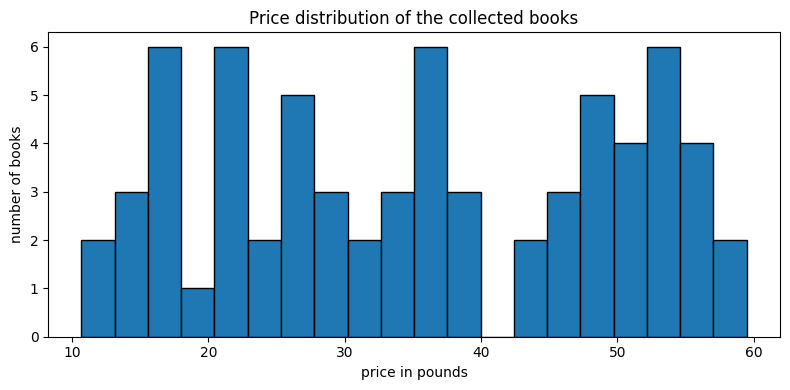

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df_books["price_number"].dropna(), bins=20, edgecolor="black")
plt.title("Price distribution of the collected books")
plt.xlabel("price in pounds")
plt.ylabel("number of books")
plt.tight_layout()
plt.show()

### Step 17. Want all 1000 books

Change the limit and run again. Fifty pages gives the whole shop.

Do not run this during class. Each page with json extraction costs several
credits, so 50 pages is a large bill on a free account. Try it at home once you
know how many credits you have.

In [ ]:
# full_result = app.crawl(
#     PAGE_1,
#     limit=50,
#     scrape_options={"formats": [json_format]}
# )
# print("pages:", len(full_result.data))

print("Read this cell, do not run it yet")

Read this cell, do not run it yet


## Part 3. Map the website

### Step 18. Get every link

Map returns the links of a site without reading the pages. It is fast and one call
costs one credit no matter how many links come back.

In [ ]:
map_result = app.map(BASE_URL)

print("Links found:", len(map_result.links))

Links found: 1216


In [ ]:
for link in map_result.links[:10]:
    print(link.url)

https://books.toscrape.com/catalogue/political-suicide-missteps-peccadilloes-bad-calls-backroom-hijinx-sordid-pasts-rotten-breaks-and-just-plain-dumb-mistakes-in-the-annals-of-american-politics_917/index.html
https://books.toscrape.com/catalogue/pet-sematary_726/index.html
https://books.toscrape.com/catalogue/vogue-colors-a-to-z-a-fashion-coloring-book_355/index.html
https://books.toscrape.com/catalogue/more-than-music-chasing-the-dream-1_716/index.html
https://books.toscrape.com/catalogue/kill-em-and-leave-searching-for-james-brown-and-the-american-soul_528/index.html
https://books.toscrape.com/catalogue/find-her-detective-dd-warren-8_373/index.html
https://books.toscrape.com/catalogue/twenty-yawns_773/index.html
https://books.toscrape.com/catalogue/the-songs-of-the-gods_763/index.html
https://books.toscrape.com/catalogue/jane-eyre_27/index.html
https://books.toscrape.com/catalogue/page-23.html


### Step 19. Links into a table

Each link usually carries a url, a title and a description. Some sites do not
provide all of them, so we use getattr. `getattr(link, "title", None)` means: give
me link.title, and if it does not exist give me None instead of an error.

In [ ]:
links_data = []

for link in map_result.links:
    links_data.append({
        "url": getattr(link, "url", link),
        "title": getattr(link, "title", None),
        "description": getattr(link, "description", None)
    })

df_links = pd.DataFrame(links_data)
print("Total links:", len(df_links))
df_links.head(15)

Total links: 1216


,url,title,description
0,https://books.toscrape.com/catalogue/political...,"Political Suicide: Missteps, Peccadilloes, Bad...",Just in time for the presidential election of ...
1,https://books.toscrape.com/catalogue/pet-semat...,Pet Sematary | Books to Scrape - Sandbox,Sometimes dead is better....When the Creeds mo...
2,https://books.toscrape.com/catalogue/vogue-col...,Vogue Colors A to Z: A Fashion Coloring Book |...,In this first-ever coloring book from American...
3,https://books.toscrape.com/catalogue/more-than...,More Than Music (Chasing the Dream #1) | Books...,Classical musician Maddie Taylor secretly drea...
4,https://books.toscrape.com/catalogue/kill-em-a...,Kill 'Em and Leave: Searching for James Brown ...,National Book Award winner James McBride goes ...
5,https://books.toscrape.com/catalogue/find-her-...,Find Her (Detective D.D. Warren #8) | Books to...,"Flora Dane is a victim. Seven years ago, caref..."
6,https://books.toscrape.com/catalogue/twenty-ya...,Twenty Yawns | Books to Scrape - Sandbox,Featuring lyrical text and beautiful illustrat...
7,https://books.toscrape.com/catalogue/the-songs...,The Songs of the Gods | Books to Scrape - Sandbox,"The Power of Dream ""It has been ages since the..."
8,https://books.toscrape.com/catalogue/jane-eyre...,Jane Eyre | Books to Scrape - Sandbox,Orphaned into the household of her Aunt Reed a...
9,https://books.toscrape.com/catalogue/page-23.html,All products | Books to Scrape - Sandbox,None


### Step 20. Sort the links into groups

This is why map matters. We can see the shape of the whole site before spending
credits on it.

In [ ]:
page_links     = df_links[df_links["url"].str.contains("page-", case=False, na=False)]
category_links = df_links[df_links["url"].str.contains("category", case=False, na=False)]

print("Listing pages   :", len(page_links))
print("Category pages  :", len(category_links))
print("All other links :", len(df_links) - len(page_links) - len(category_links))
print()
print("Some category pages:")
category_links.head(8)[["url", "title"]]

Listing pages   : 145
Category pages  : 154
All other links : 917

Some category pages:


,url,title
10,https://books.toscrape.com/catalogue/category/...,Books | \n Books to Scrape - Sandbox
21,https://books.toscrape.com/catalogue/category/...,Books | \n Books to Scrape - Sandbox
25,https://books.toscrape.com/catalogue/category/...,Historical Fiction | \n Books to Scrape - ...
30,https://books.toscrape.com/catalogue/category/...,Sequential Art | \n Books to Scrape - Sandbox
34,https://books.toscrape.com/catalogue/category/...,Books | \n Books to Scrape - Sandbox
62,https://books.toscrape.com/catalogue/category/...,Nonfiction | \n Books to Scrape - Sandbox
69,https://books.toscrape.com/catalogue/category/...,Short Stories | \n Books to Scrape - Sandbox
78,https://books.toscrape.com/catalogue/category/...,Books | \n Books to Scrape - Sandbox


### What we learned

1. **scrape** reads one page. With a schema it gives us a table instead of text
2. **markdown** keeps the structure of a page using simple symbols instead of HTML tags
3. **crawl** repeats that scrape over many pages, and always needs a limit
4. **map** lists the links of a site without reading them, for almost no cost
5. Any result becomes a **DataFrame** with the same pattern: one dictionary per
   item, collect them in a list, hand the list to pandas
6. Real data needs cleaning: prices arrive as text, duplicates happen, fields go
   missing

The working order for any scraping project:

```
map  ->  choose the pages  ->  scrape or crawl  ->  clean  ->  DataFrame  ->  CSV
```


### Exercises

**Exercise 1.** Scrape page 2 of the catalogue and show its 20 books as a
DataFrame.

<details>
<summary>Show answer</summary>

```python
r = app.scrape("https://books.toscrape.com/catalogue/page-2.html",
               formats=[json_format])
pd.DataFrame(r.json["books"])
```
</details>

**Exercise 2.** From df_books, show only the books that cost more than 40.

<details>
<summary>Show answer</summary>

```python
df_books[df_books["price_number"] > 40]
```
</details>

**Exercise 3.** Count how many books in df_books are in stock.

<details>
<summary>Show answer</summary>

```python
df_books["stock"].str.contains("in stock", case=False, na=False).sum()
```
</details>

**Exercise 4.** Crawl 8 pages instead of 5 and print how many books you get.

<details>
<summary>Show answer</summary>

```python
res = app.crawl(PAGE_1, limit=8, scrape_options={"formats": [json_format]})
total = sum(len(p.json.get("books", [])) for p in res.data if p.json)
print(total, "books")
```
</details>

**Exercise 5.** From df_links, print only the links that contain the word
mystery.

<details>
<summary>Show answer</summary>

```python
df_links[df_links["url"].str.contains("mystery", case=False, na=False)]
```
</details>